**Prática de Histogramas**

1) 
- Produza a imagem ‘negativa’ do arquivo ‘im_cells.png’
- Com a imagem negativa, produza a imagem original novamente. 
- Mostre lado a lado a imagem original e a negativa. Em qual deles os objetos presentes na imagem são melhor percebidos? Justifique.
- Aplique a imagem uma função logarítmica.


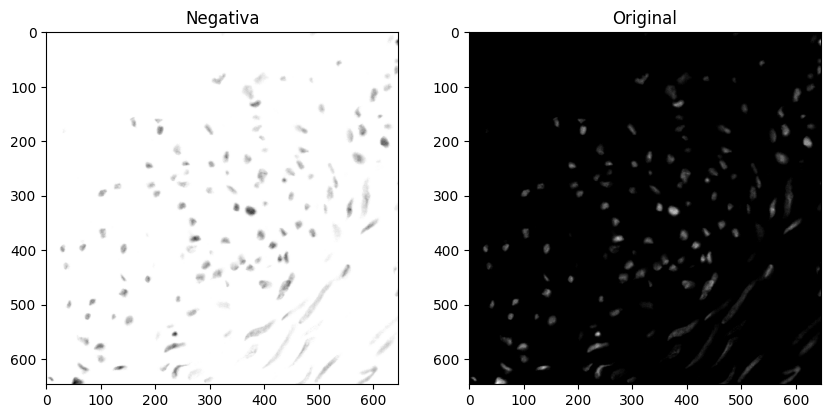

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def transformarNegativa (imagem):
    
    img_original = cv2.imread(imagem, cv2.IMREAD_GRAYSCALE)
    
    if img_original is None:
        return "Erro de imagem - Verfique se a imgaem escolhida esta certa"
    else:
        img_negativa = 255 - img_original
        
    #plot das imagens
    plt.figure(figsize=(10,5))
    
    plt.subplot(1,2,1)   
    plt.imshow(img_negativa, cmap="gray")
    plt.title("Negativa")
    
    plt.subplot(1,2,2)   
    plt.imshow(img_original,cmap="gray")
    plt.title("Original")
    
    plt.show()
    
transformarNegativa("im_cells.png")


2)
- Abra a imagem 'pout.tif' e mostre seu histograma.
- Equalize a imagem anterior e mostre novamente seu histograma. Mostra a curva de transformação (consulte https://www.mathworks.com/help/images/histogram-equalization.html)
(procurar função OpenCV)



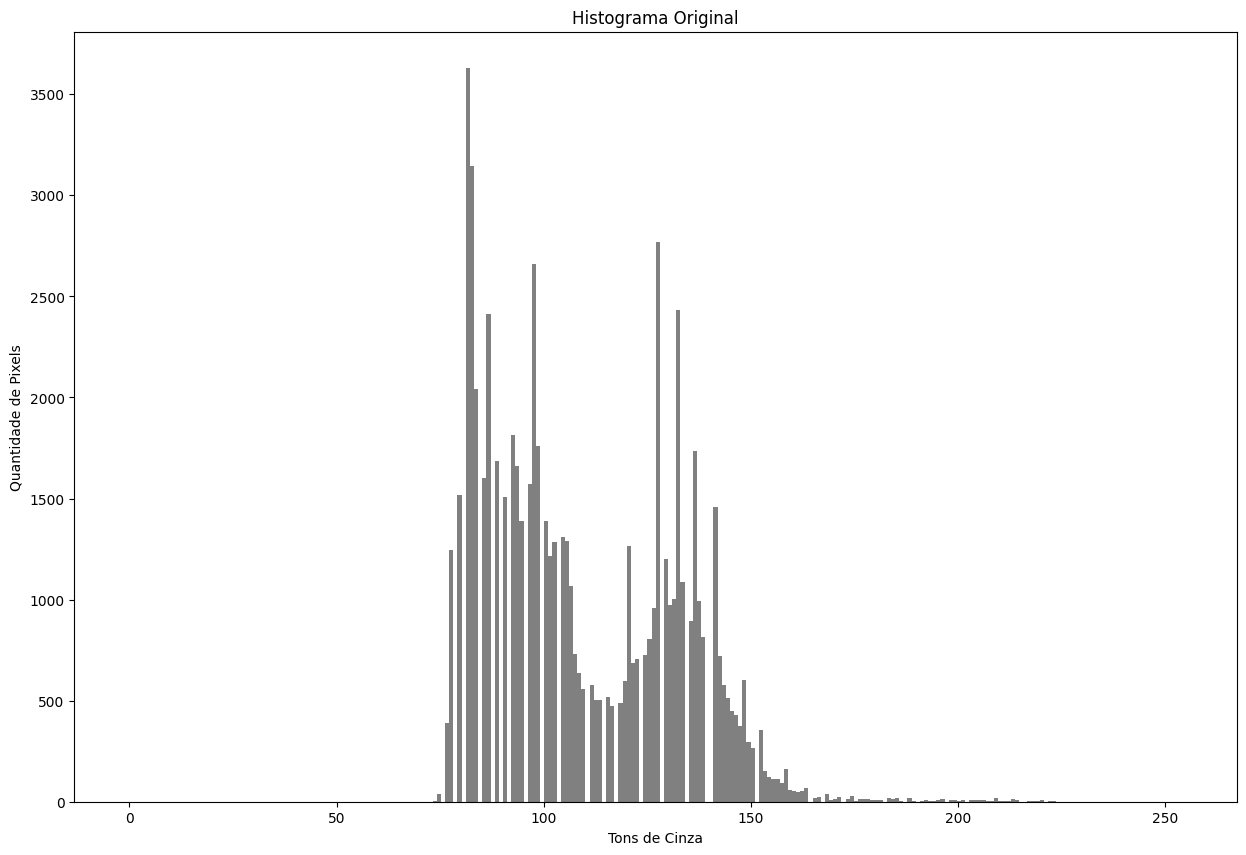

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def gerarHistograma (imagem):

    img = cv2.imread(imagem, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return "error"
    else:
        plt.figure(figsize=(15, 10))
        
        #Plotando Histogramaa sem equalizar
        hist,bins = np.histogram(img.flatten(),256,[0,255])
        plt.bar(bins[:-1], hist, width=1, color='gray')
        plt.title('Histograma Original')
        plt.xlabel('Tons de Cinza')
        plt.ylabel('Quantidade de Pixels')

gerarHistograma("pout.tif")
    


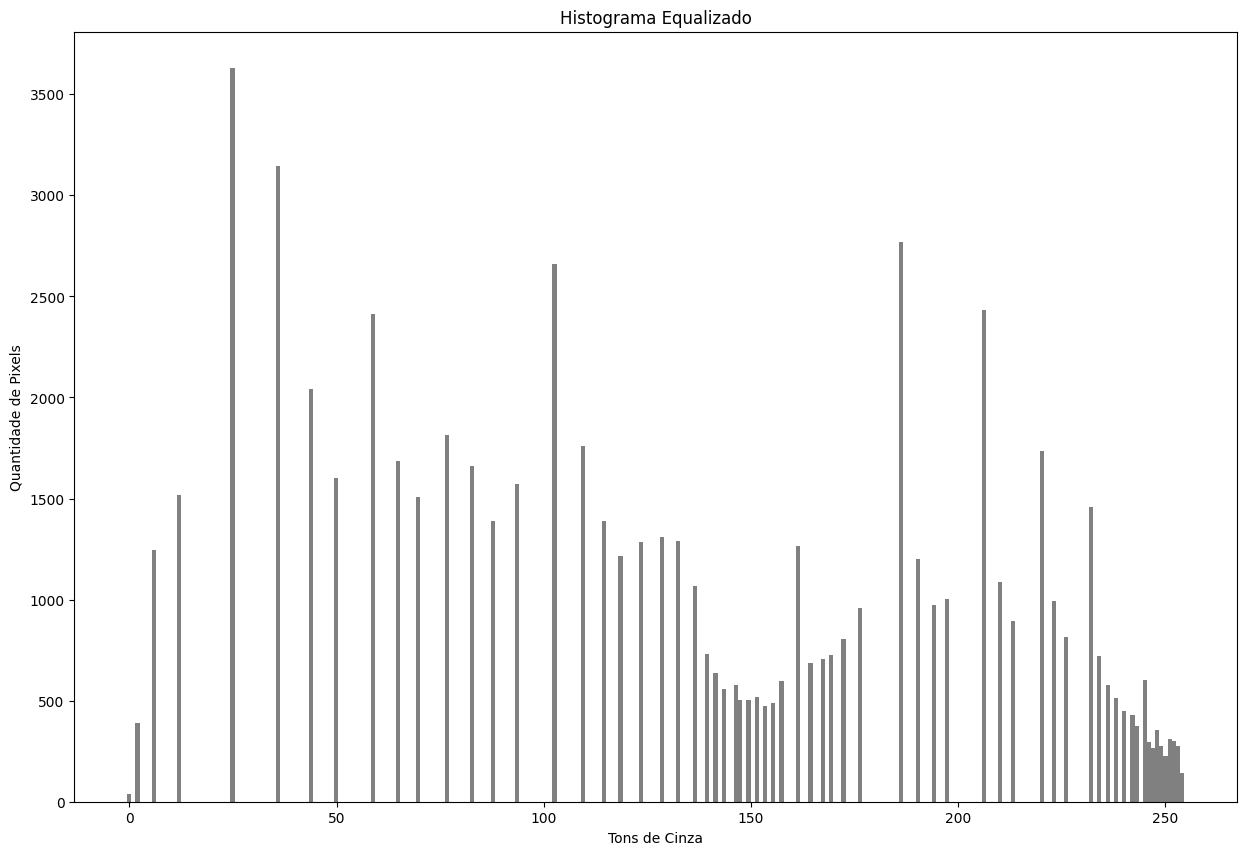

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def gerarHistogramaEqualizado(imagem):
    
    img = cv2.imread(imagem, cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return "error"
    else:
        total_pixels = img.shape[0]*img.shape[1]
        
        hist_original, _ = np.histogram(img.flatten(),256,[0,255])
        cdf = hist_original.cumsum()
        Tabela_mapeada_da_equalizacao = np.round((cdf/total_pixels)*255).astype(np.uint32)
        
        img_equalizada = Tabela_mapeada_da_equalizacao[img]
        
        plt.figure(figsize=(15, 10))
        
        hist_eq,bins_eq = np.histogram(img_equalizada.flatten(),256,[0,255]) 
        plt.bar(bins_eq[:-1], hist_eq, width=1, color='gray')
        plt.title('Histograma Equalizado')
        plt.xlabel('Tons de Cinza')
        plt.ylabel('Quantidade de Pixels')
    
gerarHistogramaEqualizado("pout.tif")

3) *Implemente* o algoritmo de equalização de histograma e aplique a imagem ‘imcells.png’. Use o mínimos de laços for - tente realizar operações diretas com matrizes e vetores do numpy
- Aplique o mesmo algortimo 2x na mesma imagem e compare os resultados

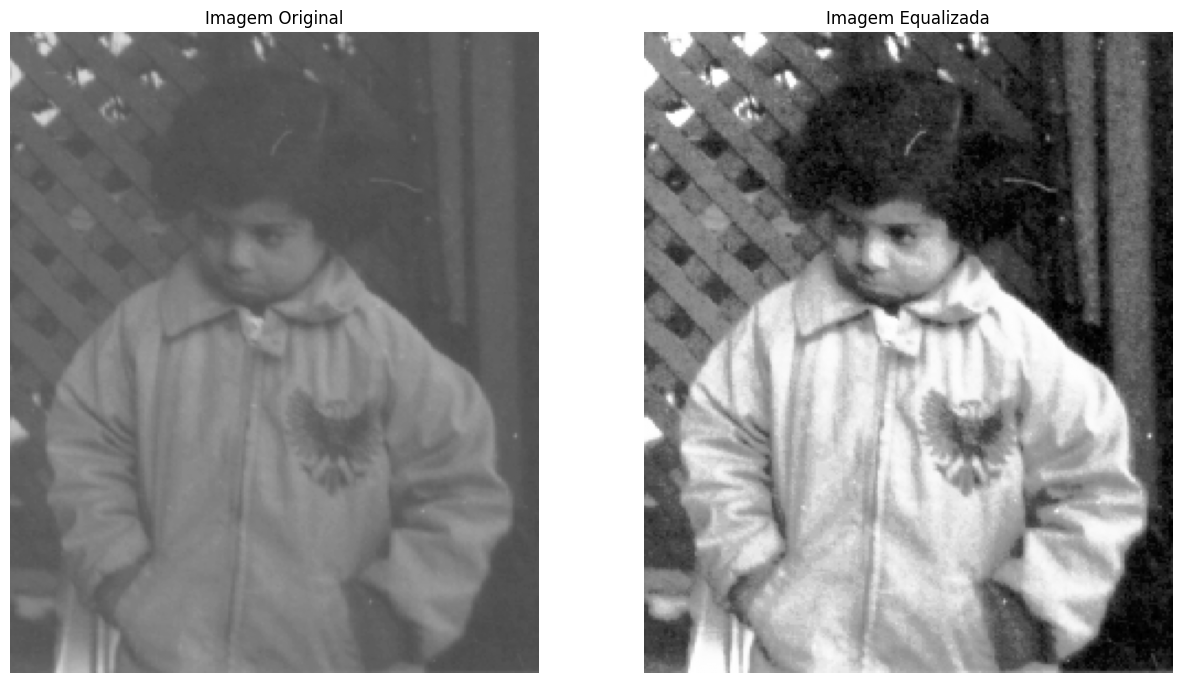

In [39]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def equalizarImagem(imagem):
    
    img = cv2.imread(imagem,cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return "error"
    else:
        total_pixels = img.shape[0]*img.shape[1]
        
        hist_original, _= np.histogram(img.flatten(),256,[0,255])
        cdf = hist_original.cumsum()
        Tabela_mapeada_da_equalizacao = np.round((cdf/total_pixels)*255).astype(np.uint32)
        
        img_equalizada = Tabela_mapeada_da_equalizacao[img]
        
        plt.figure(figsize=(15, 10))
        
        #imagem originaal 
        plt.subplot(1,2,1)
        plt.imshow(img, cmap='gray', vmin=0, vmax=255)
        plt.title('Imagem Original')
        plt.axis('off')
        
        #imagem equalizada
        plt.subplot(1,2,2)
        plt.imshow(img_equalizada, cmap='gray', vmin=0, vmax=255)
        plt.title('Imagem Equalizada')
        plt.axis('off')
        plt.show()

equalizarImagem("pout.tif")
